In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Diabetes Prediction — Pima Indians Dataset

This notebook builds and compares several classification models to predict
diabetes onset (Outcome) based on diagnostic measurements. The dataset
contains 768 patient records with 8 features (Pregnancies, Glucose,
BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age).

**Goal:** Since this is a medical screening task, the priority is
maximizing recall on the positive (diabetic) class — minimizing false
negatives matters more than overall accuracy.

In [2]:
df = pd.read_csv("16-diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Handling missing values

Several columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI)
contain zero values that are not physiologically possible — these are
treated as missing data rather than true zeros.

In [8]:
columns_to_check = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    zero_percentage = 100 * zero_count / len(df)
    print(f"{col}: {zero_count} %{zero_percentage:.2f}")

Glucose: 5 %0.65
BloodPressure: 35 %4.56
SkinThickness: 227 %29.56
Insulin: 374 %48.70
BMI: 11 %1.43


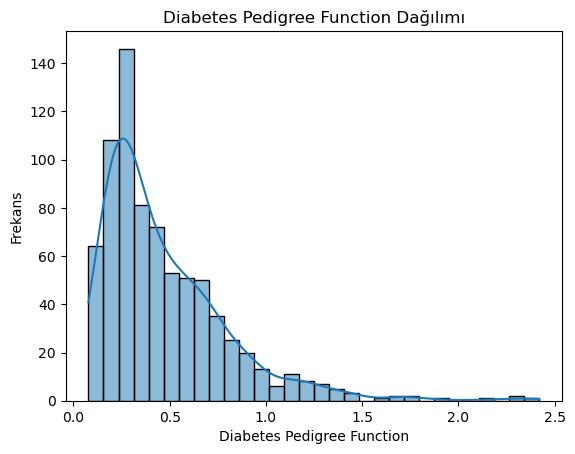

In [9]:
sns.histplot(df["DiabetesPedigreeFunction"],bins = 30 , kde = True)
plt.title("Diabetes Pedigree Function Dağılımı")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Frekans")
plt.show()

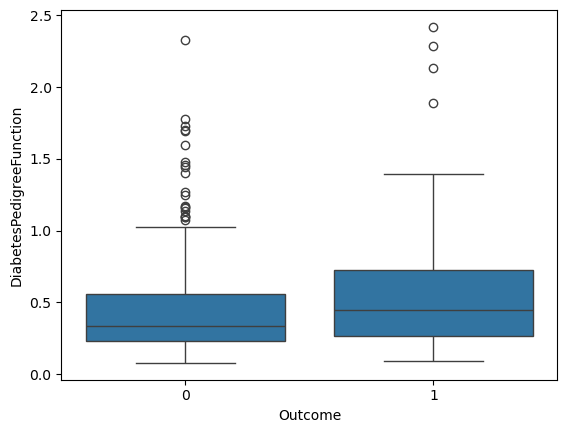

In [10]:
sns.boxplot(x = "Outcome", y = "DiabetesPedigreeFunction", data = df )
plt.show()

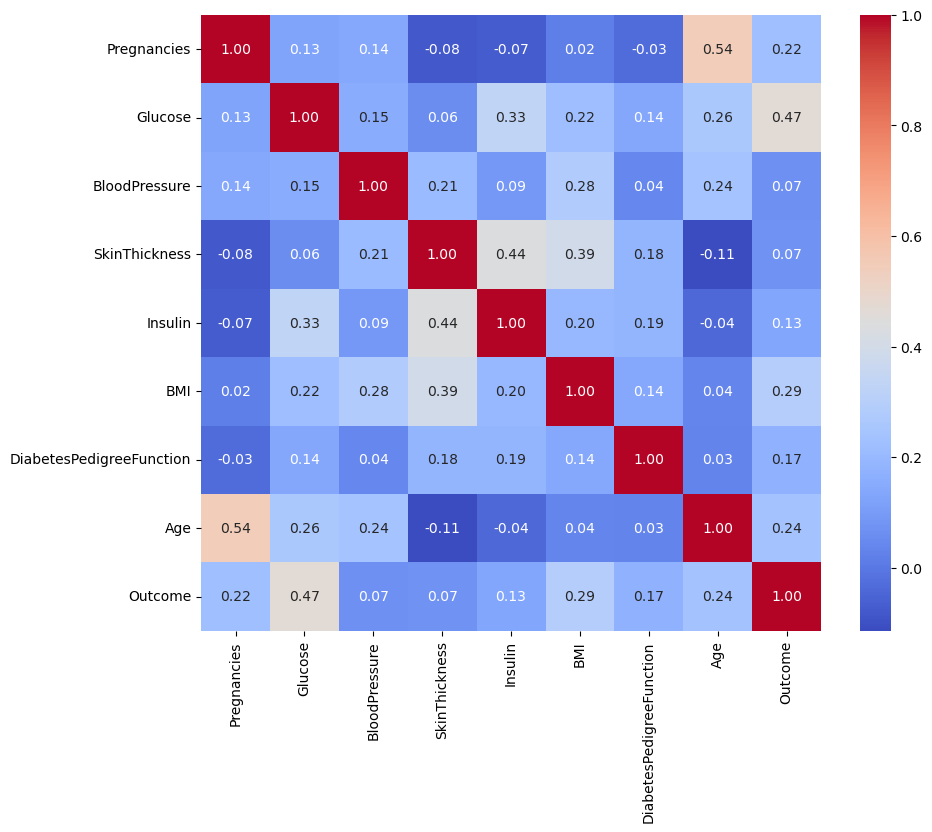

In [11]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.show()

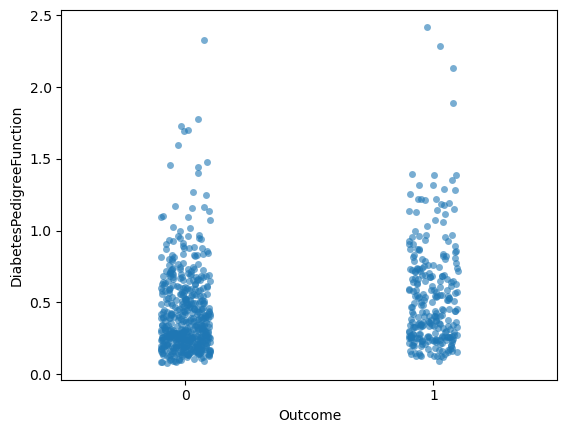

In [12]:
sns.stripplot(x = "Outcome", y ="DiabetesPedigreeFunction",data = df,jitter = True,alpha = 0.6 )
plt.show()

In [13]:
X = df.drop("Outcome",axis = 1)
y = df["Outcome"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

## Feature engineering & imputation

Instead of dropping rows with missing values (which would discard ~48% of
the data due to the Insulin column), missing values are imputed with the
train-set median. A binary `Insulin_missing` flag is added to preserve the
information that a value was originally missing.

In [14]:
X_train['Insulin_missing'] = (X_train['Insulin'] == 0).astype(int)
X_test['Insulin_missing'] = (X_test['Insulin'] == 0).astype(int)

In [15]:
columns_to_fill = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] != 0][col].median()
    medians[col] = median_value
    X_train[col] = X_train[col].replace(0,median_value)

for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0,medians[col]) 

In [16]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model comparison

Multiple classifiers are trained and evaluated on the same train/test
split, using `class_weight='balanced'` where supported to address the
class imbalance (500 negative vs. 268 positive cases).

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
logistic = LogisticRegression(class_weight='balanced')
logistic.fit(X_train_scaled,y_train)
logistic_pred = logistic.predict(X_test_scaled)
print(accuracy_score(y_test,logistic_pred))
print(classification_report(y_test,logistic_pred))
print(confusion_matrix(y_test,logistic_pred))

0.7207792207792207
              precision    recall  f1-score   support

           0       0.85      0.73      0.79       108
           1       0.52      0.70      0.60        46

    accuracy                           0.72       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.75      0.72      0.73       154

[[79 29]
 [14 32]]


In [19]:
from sklearn.svm import SVC
svc = SVC(class_weight='balanced')
svc.fit(X_train_scaled,y_train)
svc_pred = svc.predict(X_test_scaled)
print(accuracy_score(y_test,svc_pred))
print(classification_report(y_test,svc_pred))
print(confusion_matrix(y_test,svc_pred))

0.7207792207792207
              precision    recall  f1-score   support

           0       0.87      0.70      0.78       108
           1       0.52      0.76      0.62        46

    accuracy                           0.72       154
   macro avg       0.70      0.73      0.70       154
weighted avg       0.77      0.72      0.73       154

[[76 32]
 [11 35]]


In [20]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(class_weight='balanced')
tree.fit(X_train,y_train)
tree_pred = tree.predict(X_test)
print(accuracy_score(y_test,tree_pred))
print(classification_report(y_test,tree_pred))
print(confusion_matrix(y_test,tree_pred))

0.7012987012987013
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       108
           1       0.50      0.54      0.52        46

    accuracy                           0.70       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.71      0.70      0.70       154

[[83 25]
 [21 25]]


In [21]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
knn_pred = knn.predict(X_test_scaled)
print(accuracy_score(y_test,knn_pred))
print(classification_report(y_test,knn_pred))
print(confusion_matrix(y_test,knn_pred))

0.7402597402597403
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       108
           1       0.56      0.61      0.58        46

    accuracy                           0.74       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.75      0.74      0.74       154

[[86 22]
 [18 28]]


In [22]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(class_weight='balanced')
rfc.fit(X_train,y_train)
rfc_pred = rfc.predict(X_test)
print(accuracy_score(y_test,rfc_pred))
print(classification_report(y_test,rfc_pred))
print(confusion_matrix(y_test,rfc_pred))

0.7272727272727273
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       108
           1       0.54      0.59      0.56        46

    accuracy                           0.73       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.73      0.73      0.73       154

[[85 23]
 [19 27]]


In [23]:
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB

skewed_cols = ["Insulin", "SkinThickness", "DiabetesPedigreeFunction"]
pt = PowerTransformer(method='yeo-johnson')  

X_train_nb = X_train.copy()
X_test_nb = X_test.copy()
X_train_nb[skewed_cols] = pt.fit_transform(X_train_nb[skewed_cols])
X_test_nb[skewed_cols] = pt.transform(X_test_nb[skewed_cols])

nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train)
nb_pred = nb_model.predict(X_test_nb)
print(accuracy_score(y_test,nb_pred))
print(classification_report(y_test,nb_pred))
print(confusion_matrix(y_test,nb_pred))

0.7142857142857143
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       108
           1       0.52      0.54      0.53        46

    accuracy                           0.71       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.72      0.71      0.72       154

[[85 23]
 [21 25]]


In [24]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(X_train,y_train)
ada_pred = ada.predict(X_test)
print(accuracy_score(y_test,ada_pred))
print(classification_report(y_test,ada_pred))
print(confusion_matrix(y_test,ada_pred))

0.7532467532467533
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

[[87 21]
 [17 29]]


In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
svc_params = {
     "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

## Validating with cross-validation

A single train/test split can be misleading, since results may vary with
the specific split. 5-fold cross-validation (scored on recall) is used
here to get a more reliable estimate of each model's performance.

In [27]:
grid = GridSearchCV(
    estimator= SVC(class_weight='balanced'),
    param_grid = svc_params,
    n_jobs= -1,
    cv = 5,
    scoring = "recall"
)

In [28]:
grid.fit(X_train_scaled,y_train)
y_pred = grid.predict(X_test_scaled)
print("Accuracy Score: ", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy Score:  0.7142857142857143
              precision    recall  f1-score   support

           0       0.87      0.69      0.77       108
           1       0.51      0.76      0.61        46

    accuracy                           0.71       154
   macro avg       0.69      0.73      0.69       154
weighted avg       0.77      0.71      0.73       154

[[75 33]
 [11 35]]


In [29]:
grid.best_params_

{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

In [30]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": logistic,
    "SVC": svc,
    "Decision Tree": tree,
    "KNN": knn,
    "Random Forest": rfc,
    "AdaBoost": ada,
}

for name, model in models.items():
    data = X_train_scaled if name in ["Logistic Regression", "SVC", "KNN"] else X_train
    scores = cross_val_score(model, data, y_train, cv=5, scoring='recall')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression: 0.7434 (+/- 0.0747)
SVC: 0.7612 (+/- 0.0546)
Decision Tree: 0.5765 (+/- 0.1260)
KNN: 0.5902 (+/- 0.0571)
Random Forest: 0.6078 (+/- 0.0905)
AdaBoost: 0.6082 (+/- 0.0955)


## Conclusion

Cross-validation shows that **SVC** achieves the best and most stable
recall (~0.76) on the diabetic class, outperforming tree-based ensembles
(Random Forest, AdaBoost) which looked competitive on a single split but
underperformed under cross-validation. Hyperparameter tuning via
GridSearchCV confirmed the default SVC configuration was already close to
optimal, with no meaningful further gain.

**Final model:** SVC (class_weight='balanced'), recall ≈ 0.76,
accuracy ≈ 0.72–0.74 on the held-out test set.